In [2]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

In [3]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [4]:
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [5]:
def t(string):
    return parse_time(string).datetime

In [6]:
def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [7]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [8]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [9]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [10]:
indices_array = np.array(indices)
incomplete_file_ind = [5, 18, 26, 29]

In [11]:
for ind in incomplete_file_ind:
    sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[ind], top100['end_UTC'].iloc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    sci_query

    sci_files = Fido.fetch(sci_query)
    sci_files = sorted(sci_files)
    
    
    sci_data_A = Product(sci_files[0])
    sci_data_B = Product(sci_files[1])
    
    df_A = get_stix_df(sci_data_A, energy_ranges)
    df_B = get_stix_df(sci_data_B, energy_ranges)
    
    combined_df = pd.concat([df_A, df_B])
    
    combined_df = combined_df.sort_index()
    
    df = combined_df[~combined_df.index.duplicated(keep="first")]

    df_list[ind]=df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [12]:
exclude = [26, 33, 35, 36, 55, 56, 58, 59, 61, 66, 70, 77, 80, 83, 90, 96]

In [13]:
for df in df_list:
    df.index = t(df.index)

In [14]:
df_list[0].index

DatetimeIndex(['2024-07-22 21:25:24.318000', '2024-07-22 21:25:44.318000',
               '2024-07-22 21:26:04.318000', '2024-07-22 21:26:24.318000',
               '2024-07-22 21:26:44.318000', '2024-07-22 21:27:04.318000',
               '2024-07-22 21:27:24.318000', '2024-07-22 21:27:44.318000',
               '2024-07-22 21:28:04.318000', '2024-07-22 21:28:24.318000',
               ...
               '2024-07-23 03:29:15.818000', '2024-07-23 03:29:20.318000',
               '2024-07-23 03:29:24.868000', '2024-07-23 03:29:29.568000',
               '2024-07-23 03:29:34.168000', '2024-07-23 03:29:38.668000',
               '2024-07-23 03:29:43.318000', '2024-07-23 03:29:48.068000',
               '2024-07-23 03:29:52.768000', '2024-07-23 03:29:57.418000'],
              dtype='datetime64[us]', length=12851, freq=None)

In [15]:
for index, df in enumerate(df_list):
    x = pd.infer_freq(df.index)
    if x!=None:
        print(index, x)

In [16]:
df_list[0].resample(dt.timedelta(seconds=1))

In [17]:
filtered0 = savgol_filter(df_list[0]['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)

In [18]:
r = top100['solo_position_AU_distance'].loc[indices[0]]
flare0 = df_list[0][df_list[0]['25.0 keV-50.0 keV']>10/r**2]
tstart0 = flare0.index[0]
tend0 = flare0.index[-1]

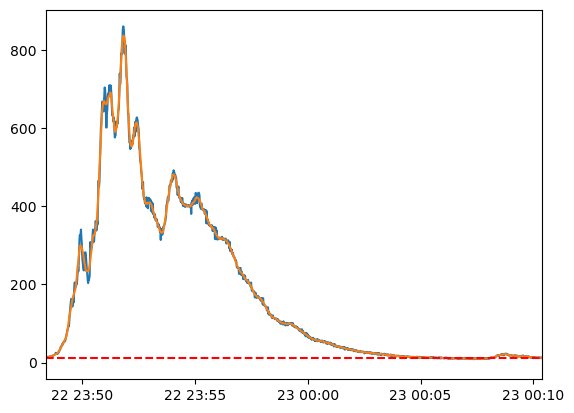

In [19]:
plt.plot(df_list[0].index, df_list[0]['25.0 keV-50.0 keV'])
plt.plot(df_list[0].index, filtered0)
plt.xlim(t(tstart0), t(tend0))
plt.axhline(10/r**2, 0, 1, linestyle = 'dashed', color='red')

In [20]:
df_filtered_78 = df_list[78].copy()
filtered78_1 = savgol_filter(df_list[78]['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
filtered78_2 = savgol_filter(df_list[78]['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

df_filtered_78['25.0 keV-50.0 keV'] = filtered78_1
df_filtered_78['50.0 keV-100.0 keV'] = filtered78_2

In [21]:
r78 = top100['solo_position_AU_distance'].loc[indices[78]]
flare78 = df_filtered_78[df_filtered_78['25.0 keV-50.0 keV']>10/r78**2]
tstart78 = flare78.index[0]
tend78 = flare78.index[-1]

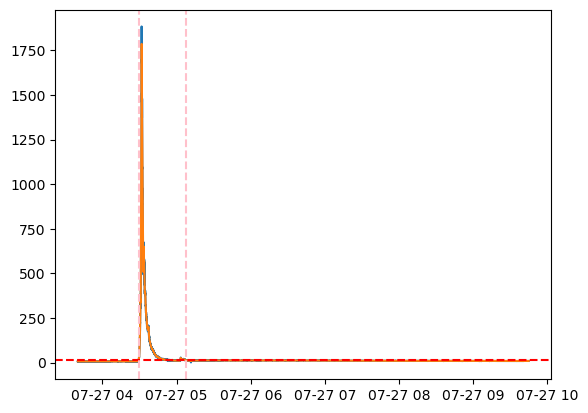

In [25]:
plt.plot(df_list[78].index, df_list[78]['25.0 keV-50.0 keV'])
plt.plot(df_list[78].index, df_filtered_78['25.0 keV-50.0 keV'])
#plt.xlim(t(tstart0), t(tend0))
plt.axhline(10/r78**2, 0, 1, linestyle = 'dashed', color='red')
plt.axvline(t(tstart78), 0, 1, linestyle = 'dashed', color='pink')
plt.axvline(t(tend78), 0, 1, linestyle = 'dashed', color='pink')

In [26]:
df_list_refined = df_list.copy()
for ind in indices:
    if ind in exclude:
        df_list_refined[ind]='excluded'

indices_refined = list(set(indices)-set(top100.index[exclude]))
    

In [27]:
df_list_filtered = []
for loc, ind in enumerate(indices):
    if ind in indices_refined:
        df_filtered  = df_list[loc].copy()
        
        filtered_2550 = savgol_filter(df_list[loc]['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
        filtered_50100 = savgol_filter(df_list[loc]['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

        df_filtered['25.0 keV-50.0 keV'] = filtered_2550
        df_filtered['50.0 keV-100.0 keV'] = filtered_50100

        df_list_filtered.append(df_filtered)
        
    if ind not in indices_refined:
        df_list_filtered.append('excluded')
        

In [28]:
data=np.zeros((len(indices_refined), 9))

In [29]:
filtered_stats_df = pd.DataFrame(data, columns = ('flare_list_id', 'peak_counts', 'number_of_peaks', 'rise_time', 'decay_time', 'peak_counts (50-100 keV)', 'rise_time (50-100 keV)', 'decay_time (50-100 keV)', 'comments'))

In [30]:
filtered_stats_df['flare_list_id'] = filtered_stats_df['flare_list_id'].astype(int)
label = 0
for loc, ind in enumerate(indices):
    if loc not in exclude:
        filtered_stats_df.loc[label, 'flare_list_id'] = int(ind)
        label+=1

In [31]:
filtered_stats_df['rise_time'] = filtered_stats_df['rise_time'].astype(str)
filtered_stats_df['decay_time'] = filtered_stats_df['decay_time'].astype(str)
filtered_stats_df['rise_time (50-100 keV)'] = filtered_stats_df['rise_time (50-100 keV)'].astype(str)
filtered_stats_df['decay_time (50-100 keV)'] = filtered_stats_df['decay_time (50-100 keV)'].astype(str)

In [33]:
label=0
i=0
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        
        r = top100['solo_position_AU_distance'].loc[ind]
        
        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = flare.index[-1]

        plot_df.truncate(t(tstart), t(tend))
        peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
        peak_counts_scaled = peak_counts/r**2
        filtered_stats_df.loc[label, 'peak_counts'] = peak_counts_scaled

        peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
        rise_time = peak_loc - tstart
        decay_time = tend - peak_loc
        filtered_stats_df.loc[label, 'rise_time'] = str(rise_time).split(" ")[-1]
        filtered_stats_df.loc[label, 'decay_time'] = str(decay_time).split(" ")[-1]

        peak_counts_50_100 = np.max(plot_df['50.0 keV-100.0 keV'])
        peak_counts_50_100_scaled = peak_counts_50_100/r**2
        filtered_stats_df.loc[label, 'peak_counts (50-100 keV)'] = peak_counts_50_100_scaled
        
        flare_50_100 = plot_df[plot_df['50.0 keV-100.0 keV']>10/r**2]

        if flare_50_100.empty:
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = np.nan
        
        if not flare_50_100.empty:
            tstart_50_100 = flare_50_100.index[0]
            tend_50_100 = flare_50_100.index[-1]
            
            peak_loc_50_100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] == peak_counts_50_100][0]
            rise_time_50_100 = peak_loc_50_100 - tstart_50_100
            decay_time_50_100 = tend_50_100 - peak_loc_50_100
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = str(rise_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = str(decay_time_50_100).split(" ")[-1]

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        filtered_stats_df.loc[label, 'number_of_peaks'] = len(peaks)
        #peak_locs[label]=peaks

        label+=1
    i+=1

In [34]:
filtered_stats_df['comments'] = filtered_stats_df['comments'].astype(str)

for i in range(len(indices_refined)):
    filtered_stats_df.loc[i, 'comments'] = ' '

In [35]:
def print_full(x):
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 2000)
    pd.set_option('display.float_format', '{:20,.2f}'.format)
    pd.set_option('display.max_colwidth', None)
    print(x)
    pd.reset_option('all')

In [36]:
print_full(filtered_stats_df)

    flare_list_id          peak_counts      number_of_peaks        rise_time       decay_time  peak_counts (50-100 keV) rise_time (50-100 keV) decay_time (50-100 keV) comments
0           17678               990.39                 3.00         00:03:23         00:18:31                    172.76               00:02:20                00:02:31         
1           16121             7,324.69                 1.00         00:01:10  02:09:20.100000                  1,793.52               00:00:50         02:09:19.100000         
2           12921               738.80                 1.00         00:04:37         00:07:23                      7.93                    NaN                     NaN         
3           15873             2,082.48                 2.00         00:03:29         00:07:27                    276.50               00:00:36                00:02:18         
4            8972               128.09                 3.00  00:08:12.500000  00:16:58.550000                     17.32 

C:\Users\derva\AppData\Local\Temp\ipykernel_11108\839608096.py:8: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.reset_option('all')
C:\Users\derva\AppData\Local\Temp\ipykernel_11108\839608096.py:8: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.reset_option('all')


In [37]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
        
        plot_df = sci_df.truncate(start, end)
             
        plot_df.index = t(plot_df.index)

        r = top100['solo_position_AU_distance'].loc[ind]
        
        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = flare.index[-1]
    
        # if t(tend) in plot_df.index:
        #     plt.axvline(t(tend), 0, 1, color = 'pink', linestyle = 'dotted', label = 'Estimated Start/End')
        # if t(tstart) in plot_df.index:
        #     plt.axvline(t(tstart), 0, 1, color = 'pink', linestyle = 'dotted')

        plot_df = plot_df.truncate(t(tstart), t(tend))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
        # plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
        # plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
        # plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
        # plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        peak_locs[i]=peaks
        plt.scatter(plot_df.index[peak_locs[i]], plot_df['25.0 keV-50.0 keV'].iloc[peak_locs[i]], color='black', marker='*')
        
        plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        #fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered_cropped/top_100_flares_science_data_plot"+str(i)+"_filtered_cropped.png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_11108\1770586536.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [38]:
rise_time_td = pd.to_timedelta(filtered_stats_df['rise_time'])
decay_time_td = pd.to_timedelta(filtered_stats_df['decay_time'])

durations = rise_time_td+decay_time_td
durations = durations.dt.total_seconds()

Text(0.5, 1.0, '25-50 keV')

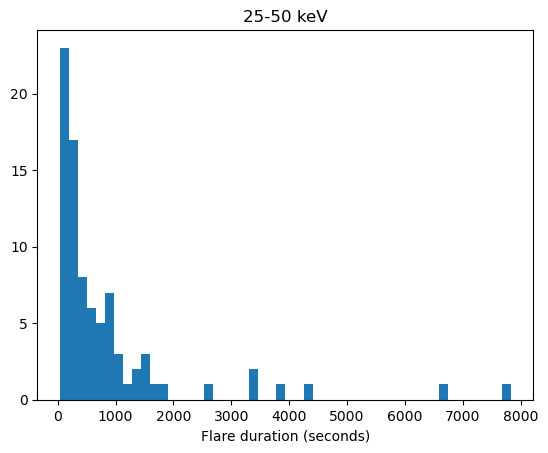

In [39]:
plt.hist(durations, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('25-50 keV')
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_hist_filtered.png", bbox_inches='tight')

Text(0, 0.5, 'Scaled peak counts')

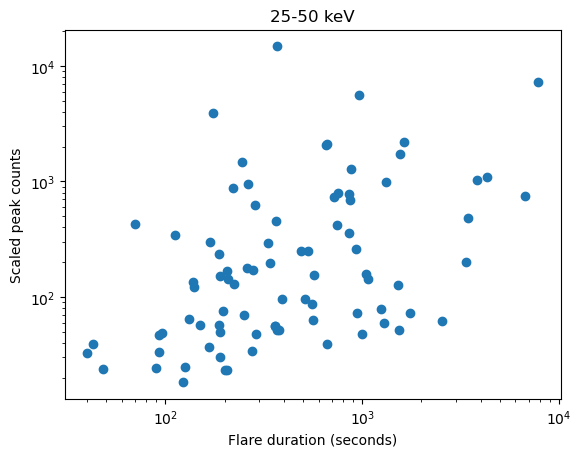

In [40]:
plt.scatter(durations, filtered_stats_df['peak_counts'])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.ylabel('Scaled peak counts')
#plt.xlim(0, 2000)
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_counts_filtered.png", bbox_inches='tight')

In [41]:
rise_time_50_100_td = pd.to_timedelta(filtered_stats_df['rise_time (50-100 keV)'])
decay_time_50_100_td = pd.to_timedelta(filtered_stats_df['decay_time (50-100 keV)'])

durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
durations_50_100 = durations_50_100.dt.total_seconds()

Text(0.5, 1.0, '50-100 keV')

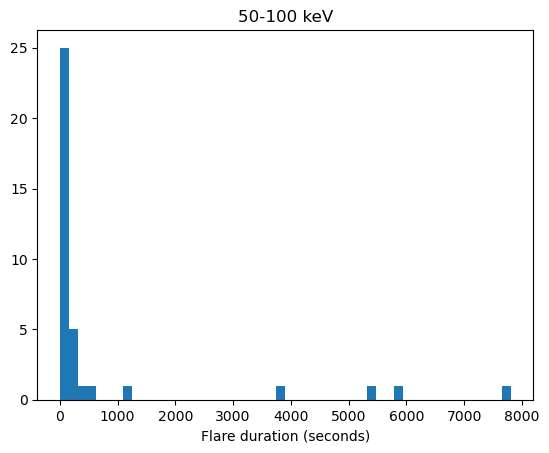

In [42]:
plt.hist(durations_50_100, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('50-100 keV')
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_hist_50_100_filtered.png", bbox_inches='tight')

Text(0, 0.5, 'Scaled peak counts')

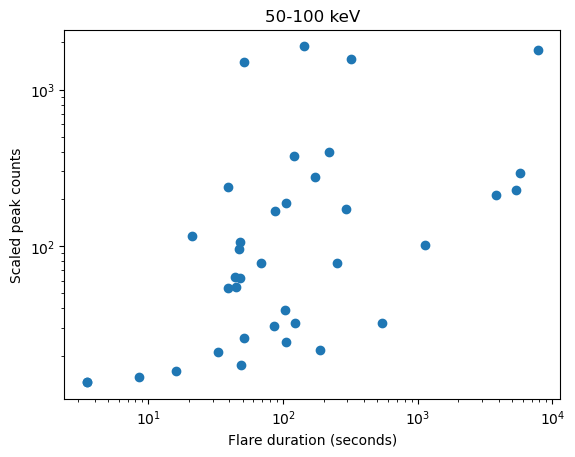

In [43]:
plt.scatter(durations_50_100, filtered_stats_df['peak_counts (50-100 keV)'])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.ylabel('Scaled peak counts')
#plt.xlim(-50, 2000)
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_counts_50_100_filtered.png", bbox_inches='tight')

In [44]:
peak_ratios = filtered_stats_df['peak_counts (50-100 keV)']/filtered_stats_df['peak_counts']

Text(0.5, 0, 'Ratio of peaks (50-100 keV:25-50 keV)')

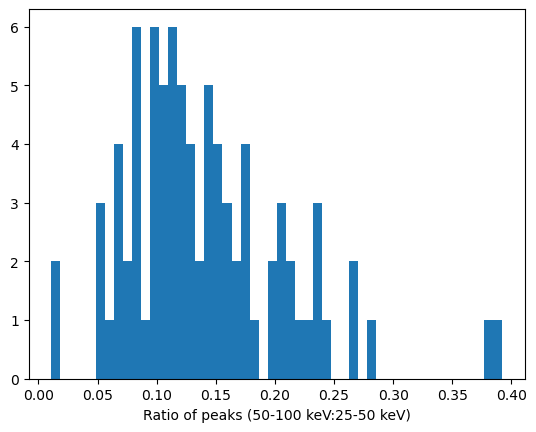

In [45]:
plt.hist(peak_ratios, bins=50)
plt.xlabel('Ratio of peaks (50-100 keV:25-50 keV)')
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/peak_ratio_hist_filtered.png", bbox_inches='tight')